# Spam Email Detection via Segmented Logistic Regression
This notebook implements an auto-segmented logistic regression model for detecting spam emails using the *Spam Email Detection Dataset Clean and ML Ready* available via Kaggle (https://www.kaggle.com/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready).

The proposed approach utilises an unsupervised machine learning approach to identify segments in the feature space, learning a mapping to these clusters to define segments, and then fitting subsequent logistic regression models to each segment.

## 1. Imports & Dataset

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import k_means
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, silhouette_score
import matplotlib.pyplot as plt

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ssssws/spam-email-detection-dataset-clean-and-ml-ready")

print("Path to dataset files:", path)

100%|██████████| 616k/616k [00:00<00:00, 101MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/versions/1


In [4]:
df = pd.read_csv(path+'/spam_email_dataset.csv')
df

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,22,136,0,5,1,0,0,fefsrcz@unknownmail.cc,unknownmail.cc,0.68,8,1,0,29,1,1,1
9996,9996,You are selected!!!,click now free guarantee free win click now wi...,26,158,0,2,0,0,0,yxyctux@chealdealz.xyz,chealdealz.xyz,0.76,2,3,0,29,0,1,1
9997,9997,You are selected!!!,offer cash win limited click now cash limited ...,21,124,0,3,1,1,1,tkvqnki@unknownmail.cc,unknownmail.cc,0.69,6,1,0,25,0,1,1
9998,9998,Meeting Reminder,budget review - Many result affect idea.,7,40,0,1,0,2,1,wmvnrbn@outlook.com,outlook.com,0.80,7,2,0,18,0,0,0


## 2. Modelling

In [5]:
# All available numeric features are used by the model
X = df._get_numeric_data().drop(columns=['label']).to_numpy()
y = df['label'].to_numpy()

In [23]:
class Model:
    """
    This class creates an instance of a segmentation logistic regression model. The model contains four steps:
    1. (optional) Standardise the input variables.
    2. Apply k-means clustering to identify clusters within the input data.
    3. Train a decision tree classifier to learn a logical mapping from input data to the clusters -> segments.
    4. For each segment, fit a logistic regression model.
    """
    def __init__(self, standardise:bool=None, n_clusters:int=None, max_tree_depth:int=None):
        """
        This function creates an instance of the model.

        Args:
            standardise (bool): Used to override the option in `process_data()`, a boolean flag to
                                indicate whether the input data should be standardised (defaults to None).
            n_clusters (int): Used to override the option in `fit_segments()`, the number of clusters
                              to use in the k-means algorithm (defaults to None).
            max_tree_depth (int): Used to override the option in `fit_segments()`, the maximum depth
                                  of the decision tree (defaults to None).
        """
        self._standardise = standardise
        self._n_clusters = n_clusters
        self._max_tree_depth = max_tree_depth

    def process_data(self, X:np.ndarray, y:np.ndarray, standardise:bool=True, test_size:float=0.3):
        """
        This function processes input data for training and validation, performing a train-test split
        and standardisation where required.

        Args:
            X (np.ndarray): The input data.
            y (np.ndarray): The target variable corresponding to the input data.
            standardise (bool): Flag to indicate whether the data should be standardised (defaults to True).
            test_size (float): Portion of data to reserve for testing (defaults to 0.3).
        """
        # Train-test split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, test_size=test_size)

        # Creating standardisation function if required
        standardise = self._standardise if self._standardise is not None else standardise
        if standardise:
            self.scaler = StandardScaler().fit(X)

    def fit_segments(self, k_means_kwargs:dict={}, tree_kwargs:dict={}):
        """
        This function performs the clustering and segmentation steps, applying the k-means clustering algorithm
        to identify initial clusters followed by training a decision tree to learn a mapping to these clusters.

        Args:
            k_means_kwargs (dict): The sklearn `k_means()` function optional key word arguments passed as a dictionary.
            tree_kwargs (dict): The sklearn `DecisionTreeClassifier()` class optional key word arguments passed as a dictionary.
        """
        assert hasattr(self, 'X_train'), 'Please provide some training data to the model using `process_data()`.'

        # If standardisation is being used, then apply it
        if hasattr(self, "scaler"):
            X_train = self.scaler.transform(self.X_train)
        else:
            X_train = self.X_train

        # Taking the overridden n_clusters argument from initialisation, otherwise defaulting to 5
        if self._n_clusters is not None:
            k_means_kwargs['n_clusters'] = self._n_clusters
        if 'n_clusters' not in k_means_kwargs.keys():
            k_means_kwargs['n_clusters'] = 5

        # Taking the overridden max_tree_depth argument from initialisation, otherwise defaulting to 3
        if self._max_tree_depth is not None:
            tree_kwargs['max_depth'] = self._max_tree_depth
        if 'max_depth' not in tree_kwargs.keys():
            tree_kwargs['max_depth'] = 3

        # Fitting both steps
        clusters = k_means(X_train, **k_means_kwargs)[1]
        self.tree = DecisionTreeClassifier(**tree_kwargs).fit(X_train, clusters)
        self.n_segments = np.unique(self.tree.predict(X_train)).shape[0]

    def fit_lr(self, **kwargs):
        """
        This function fits a logistic regression model for each segment defined by the trained decision tree.

        Args:
            **kwargs: Key word arguments for the sklearn `LogisticRegression()` class.
        """
        assert hasattr(self, 'tree'), 'Please fit the decision tree classifier using `fit_segments()`.'

        # If standardisation is being used, then apply it
        if hasattr(self, "scaler"):
            X_train = self.scaler.transform(self.X_train)
        else:
            X_train = self.X_train
        segments = self.tree.predict(X_train)

        # A dictionary to store all trained models
        self.lrs = {}

        # Training each model
        for seg in sorted(np.unique(segments)):
            X, y = X_train[segments==seg], self.y_train[segments==seg]
            self.lrs[seg] = LogisticRegression(**kwargs).fit(X, y)

    def fit(self, X:np.ndarray, y:np.ndarray):
        """
        This function provides an efficient way to process data and fit all components of the model on some provided
        data using all default settings for the component fit methods.

        Args:
            X (np.ndarray): The input data.
            y (np.ndarray): The target variable corresponding to the input data.
        """
        self.process_data(X, y)
        self.fit_segments()
        self.fit_lr()

    def predict(self, X:np.ndarray):
        """
        This function uses the trained decision tree and logistic regression models to make a
        prediction on some provided data.

        Args:
            X (np.ndarray): The data to predict for.

        Returns:
            np.ndarray: The logistic regression outputs (predictions).
            np.ndarray: The modelled segments.
        """
        assert hasattr(self, 'lrs'), 'Please fit the logistic regression models using `fit_lr()`.'

        # If standardisation is being used, then apply it
        if hasattr(self, "scaler"):
            X = self.scaler.transform(X)

        # Empty array to store outputs in
        y = np.empty(X.shape[0])

        # Make predictions
        segments = self.tree.predict(X)
        for seg in sorted(np.unique(segments)):
            y[segments==seg] = self.lrs[seg].predict(X[segments==seg])

        return y, segments

    def evaluate(self, X:np.ndarray=None, y:np.ndarray=None):
        """
        This function evaluates the effectiveness of the model by computing the area under the reciever-operator
        characteristic curve (AUC). This metric is computed at both segment-level and overall. If no data is provided,
        then the model is evaluated on the train and test datasets, returning three sets of AUCs: train, test, total.

        Args:
            X (np.ndarray): The input data (defaults to None).
            y (np.ndarray): The target variable for the input data (defaults to None).

        Returns:
            dict: AUCs for the provided data.
             or
            dict: AUCs for the training data.
            dict: AUCs for the testing data.
            dict: AUCs for both the training and testing data.
        """
        assert hasattr(self, 'lrs'), 'Please fit the logistic regression models using `fit_lr()`.'

        if X is not None and y is not None:
            # If data is provided, then just use that
            AUCs = {}
            y_pred, segments = self.predict(X)

            for seg in sorted(np.unique(segments)):
                AUCs[seg] = roc_auc_score(y[segments==seg], y_pred[segments==seg])

            AUCs['Total'] = roc_auc_score(y, y_pred)
            return AUCs

        else:
            # Otherwise, use the training and testing datasets
            AUCs_train, AUCs_test, AUCs_total = {}, {}, {}
            y_train_pred, train_segments = self.predict(self.X_train)
            y_test_pred, test_segments = self.predict(self.X_test)

            for seg in sorted(np.unique(train_segments)):
                AUCs_train[seg] = roc_auc_score(self.y_train[train_segments==seg], y_train_pred[train_segments==seg])
                AUCs_test[seg] = roc_auc_score(self.y_test[test_segments==seg], y_test_pred[test_segments==seg])
                AUCs_total[seg] = roc_auc_score(np.concatenate([self.y_train[train_segments==seg],
                                                                self.y_test[test_segments==seg]], axis=0),
                                                np.concatenate([y_train_pred[train_segments==seg],
                                                                y_test_pred[test_segments==seg]], axis=0))

            AUCs_train['Total'] = roc_auc_score(self.y_train, y_train_pred)
            AUCs_test['Total'] = roc_auc_score(self.y_test, y_test_pred)
            AUCs_total['Total'] = roc_auc_score(np.concatenate([self.y_train, self.y_test], axis=0),
                                                np.concatenate([y_train_pred, y_test_pred], axis=0))

            return AUCs_train, AUCs_test, AUCs_total

    def evaluate_segments(self, X:np.ndarray=None):
        """
        This function evaluates the effectiveness of the Silhouette coefficient on the decision tree outputs for
        some provided data. If no data is provided, then the model is evaluated on the train and test datasets,
        returning three sets of AUCs: train, test, total.

        Args:
            X (np.ndarray): The input data (defaults to None).

        Returns:
            float: Silhouette coefficient for provided data.
             or
            float: Silhouette coefficient for training data.
            float: Silhouette coefficient for testing data.
            float: Silhouette coefficient for both training and testing data.
        """
        assert hasattr(self, 'tree'), 'Please fit the decision tree classifier using `fit_segments()`.'
        assert self.n_segments > 1, 'Silhouette score can only be computed for a model with more than one segment.'

        if X is not None:
            # If standardisation is being used, then apply it
            if hasattr(self, "scaler"):
                X = self.scaler.transform(X)

            # Predict segments for data and return score
            segments = self.tree.predict(X)
            return silhouette_score(X, segments)

        else:
            # If standardisation is being used, then apply it
            if hasattr(self, "scaler"):
                X_train = self.scaler.transform(self.X_train)
                X_test = self.scaler.transform(self.X_test)

            # Predict segments
            segments_train = self.tree.predict(X_train)
            segments_test = self.tree.predict(X_test)
            segments_total = self.tree.predict(np.concatenate([X_train, X_test], axis=0))

            # Return scores
            score_train = silhouette_score(X_train, segments_train)
            score_test = silhouette_score(X_test, segments_test)
            score_total = silhouette_score(np.concatenate([X_train, X_test], axis=0), segments_total)
            return score_train, score_test, score_total



## 3. Validation

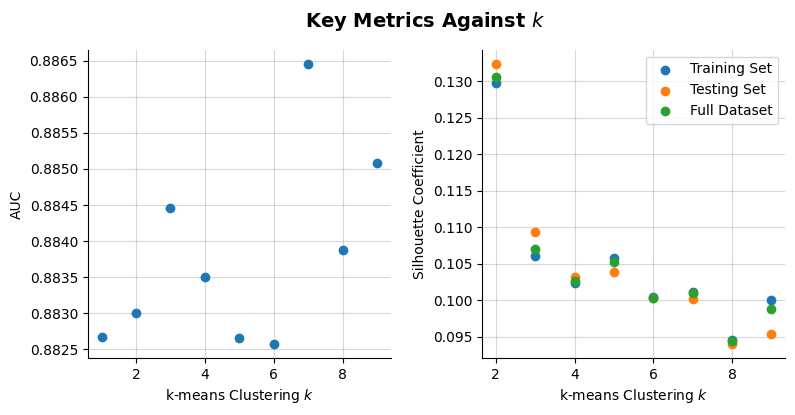

In [51]:
# Lists to store metrics in
aucs = []
train_sil, test_sil, total_sil = [], [], []

# Range of k-means clustering ks to try
Ks = np.arange(1, 10)

for k in Ks:
    # For each k, fit the model and evaluate performance
    model = Model(n_clusters=k, max_tree_depth=7)
    model.fit(X, y)
    _, _, auc = model.evaluate()
    aucs.append(auc['Total'])
    if k > 1:
        tr_s, te_s, to_s = model.evaluate_segments()
        train_sil.append(tr_s); test_sil.append(te_s); total_sil.append(to_s)

# --- Plotting ---
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
fig.subplots_adjust(wspace=0.3)

# Scatter results
ax[0].scatter(Ks, aucs, zorder=2)
ax[1].scatter(Ks[1:], train_sil, label='Training Set', zorder=2)
ax[1].scatter(Ks[1:], test_sil, label='Testing Set', zorder=2)
ax[1].scatter(Ks[1:], total_sil, label='Full Dataset', zorder=2)

# Additional formatting
for a in ax:
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.grid(alpha=0.5, zorder=1)
    a.set_xlabel("k-means Clustering $k$")

ax[1].legend()

ax[0].set_ylabel("AUC")
ax[1].set_ylabel("Silhouette Coefficient")
fig.suptitle('Key Metrics Against $k$', weight='bold', fontsize=14)

plt.show()

It is interesting to note that the *AUC* metric does not strictly increase as the complexity of the model (measured by number of clusters $k$) increases. Moreover, there is very little variance in final *AUC* across all models, a range of only $0.004$, suggesting minimal impact.

The silhouette coefficients portray a similar picture, clearly declining as more segments are introduced, suggesting that perhaps segmentation is not appropriate in this feature space.

---

**Both sets of results indicate that perhaps the approach is not well suited to the selected data. The next step is to explore alternative feature selection, feature engineering, or modelling approaches.**